In [108]:
# import packages

import numpy as np
import pandas as pd 
import math
import matplotlib.pyplot as plt

## Exercise 6.2 
Implement the Kalman filter in Example 6.7 for the Gaussian random walk model. Draw realizations of state and measurement sequences and apply the filter to it. Plot the evolution of the filtering distribution. 

Example 6.7 we observe measurements $y_k$ of the Gaussian random walk model:
$$x_k = x_{k-1} + q_{k-1}$$
$$y_k = x_k + r_k $$

where $q_{k-1} \sim N(0, Q)$, and $r_k \sim N(0, R)$. 

The information obtained up to time step $k$ is summarized by the Gaussian filtering density:
$$p(x_k | y_{1:k})  = N(x_k | m_k, P_k) $$
The Kalman filter prediction and update equations are given as:
$$ m_k^- = m_{k-1} $$
$$ P_k^- = P_{k-1} + Q $$
$$ m_k = m_k^- + \frac{P_k^-}{P_k^- + R}(y_k - m_k^-) $$
$$ P_k = P_k^- - \frac{(P_k^-)^2}{P_k^- + R}$$


### Simulation 

In [94]:
# simulation
Q = 10000
R = 10000
m0 = 0
T = 1000

q_list = np.random.normal(0, Q, size = T)
r_list = np.random.normal(0, R, size = T)


X = np.zeros(T)
Y = np.zeros(T)
X[0] = m0
Y[0] = X[0] + r_list[0]

for i in range(1, T):
    X[i] = X[i-1] + q_list[i-1]
    Y[i] = X[i] + r_list[i]

    

##### show simulation graphs 

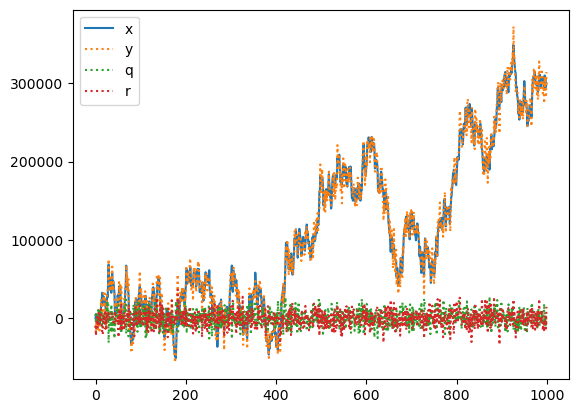

In [95]:
plt.plot(X, label = 'x')
plt.plot(Y, label = 'y', linestyle = ':')
plt.plot(q_list, label = 'q', linestyle = ':')
plt.plot(r_list, label = 'r', linestyle = ':')
plt.legend()
plt.show()

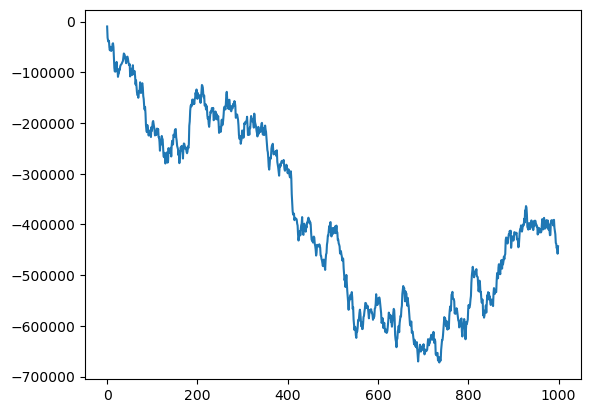

In [96]:
plt.plot(r_list.cumsum())

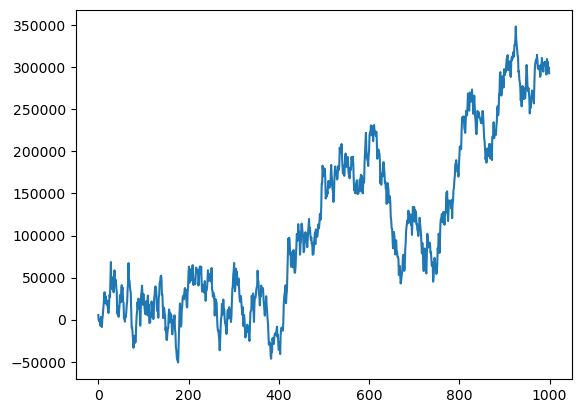

In [97]:
plt.plot(q_list.cumsum())

### Bayesian Filtering 

In [98]:
# Bayesian filtering: Y list is given. 

m_list = np.zeros(T)
m_prior_list = np.zeros(T)
P_list = np.zeros(T)

m_list[0] = m0
P_list[0] = 0

for i in range(1, T):
    m_prior = m_list[i-1]
    P_prior = P_list[i-1] + Q
    m_i = m_prior + (P_prior/(P_prior + R))*(Y[i] - m_prior)
    P_i = P_prior - (P_prior**2)/(P_prior + R)
    m_list[i] = m_i
    P_list[i] = P_i

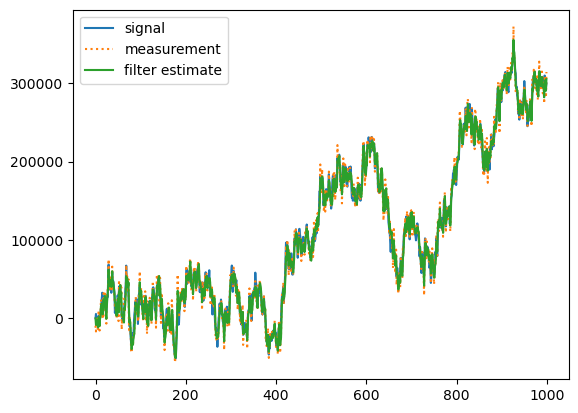

In [99]:
plt.plot(X, label = 'signal')
plt.plot(Y, label = 'measurement', linestyle = ':')
plt.plot(m_list, label = 'filter estimate')
#plt.plot(P_list, label = 'variance')
plt.legend()
plt.show()

Gaussian random walks are very like the cumulative pnl curve, which suggests that pnl might just be a set of random walks. How to identify there is real trend in the pnl??

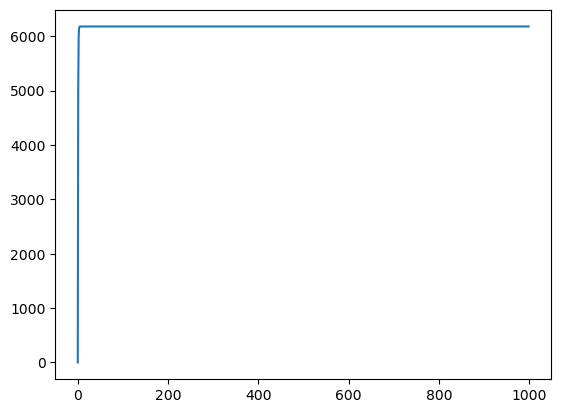

In [100]:

plt.plot(P_list, label = 'variance')

In [102]:
P_list[0:10]

array([   0.        , 5000.        , 6000.        , 6153.84615385,
       6176.47058824, 6179.7752809 , 6180.25751073, 6180.32786885,
       6180.338134  , 6180.33963167])

## Execise 6.4 

### Simulation 

In [216]:
def get_simulation(omega, q_c, R, T, x_0):
    Q = np.array([
                [(q_c * omega - q_c * math.cos(omega)*math.sin(omega))/(2*omega**3), q_c * math.sin(omega)**2/(2*omega**2)],
                 [q_c * math.sin(omega)**2/(2*omega**2), (q_c*omega + q_c * math.cos(omega) * math.sin(omega))/(2*omega)]
    ])
        
    A = np.array([[math.cos(omega), math.sin(omega)/omega], [-omega * math.sin(omega), math.cos(omega)]])
    H = np.array([[1., 0.]])

    q_list = np.random.multivariate_normal([0,0], Q, T)
    r_list = np.random.normal(0, np.sqrt(R), T)

    states = np.empty((T, 2))
    observations = np.empty(T)

    states[0] = x_0
    observations[0] = np.matmul(H, states[0]) + r_list[0]
    for i in range(1, T):
        states[i] = np.matmul(A, states[i-1]) + q_list[i-1]
        observations[i] = np.matmul(H, states[i]) + r_list[i]

    return states, observations, Q, A, H
    
def plot_state(observations, true_states, T):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(true_states[:, 0], linestyle='--', label="True Signal")
    ax.scatter(np.arange(T), observations, marker='o', label="Measurements")
    ax.set_xlabel("Time step")
    ax.legend(loc="upper left")
    fig.suptitle("Simulated data")

In [217]:
T = 100
omega = 0.5
q_c = 0.01
R = 0.1
x_0 = [0., 0.1]

states, observations, Q, A, H = get_simulation(omega, q_c, R, T, x_0)

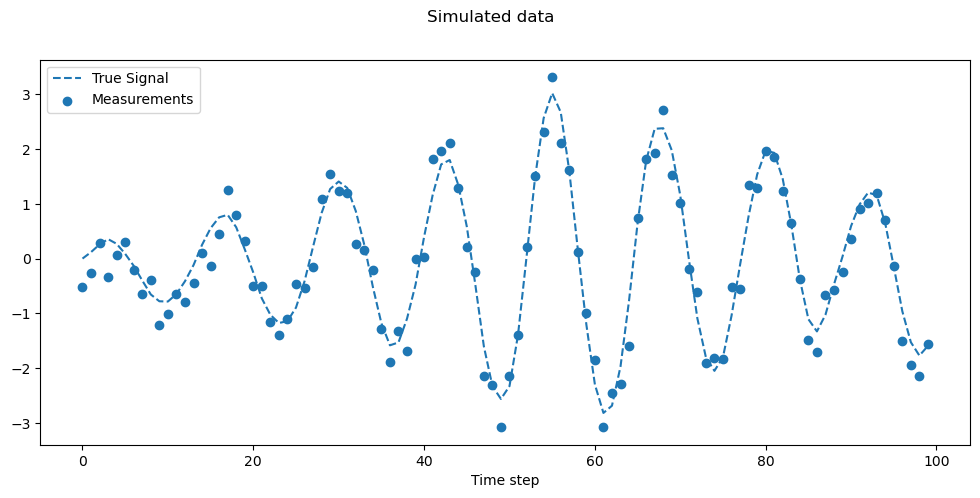

In [218]:
plot_state(observations, states, T)

### Kalman filter

In [265]:

def kalman_filter(observations, initial_state, A, H, Q, R):
    '''
    Simplified Kalman filter with constant A, H, Q and R
    '''
    T = len(observations)
    n = len(initial_state)

    M = np.empty((T, n))
    M[0] = initial_state
    P = np.empty((T, n, n))
    P[0] = Q
    
    
    for i in range(T):
        # prediction
        m_prior = A @ M[i-1]
        P_prior = A @ P[i-1] @ A.T + Q

        # update
        v_i = observations[i] - H @ m_prior
        S_i = H @ P_prior @ H.T + R
        K_i = P_prior @ H.T @ np.linalg.inv(S_i)
        m_i = m_prior + K_i @ v_i
        P_i = P_prior - K_i @ S_i @ K_i.T
        
        M[i] = m_i
        P[i] = P_i

    return M, P


In [276]:
A

array([[ 0.87758256,  0.95885108],
       [-0.23971277,  0.87758256]])

In [274]:
Q

array([[0.00317058, 0.00459698],
       [0.00459698, 0.00920735]])

In [282]:
x = np.array([0, 1])
cov = np.eye(2)
obs = 0.5
m_prior = A @ x
P_prior = A @ cov @ A.T + Q

# update
v_i = obs - H @ m_prior
S_i = H @ P_prior @ H.T + R
K_i = P_prior @ H.T @ np.linalg.inv(S_i)
new_x = m_prior + K_i @ v_i
new_cov = P_prior - K_i @ S_i @ K_i.T


print(f'cov_prior is {P_prior}')
print(f'v_i is {v_i}')
print(f'S_i is {S_i}')
print(f'K_i is {K_i}')
print(f'new_x is {new_x}')
print(f'new_cov is {new_cov}')

cov_prior is [[1.69271712 0.63570022]
 [0.63570022 0.83682072]]
v_i is [-0.45885108]
S_i is [[1.79271712]]
K_i is [[0.94421875]
 [0.35460152]]
new_x is [0.52559529 0.71487327]
new_cov is [[0.09442188 0.03546015]
 [0.03546015 0.61140046]]


In [283]:
K_i @ S_i @ K_i.T

array([[1.59829525, 0.60024006],
       [0.60024006, 0.22542026]])

In [284]:
H @ P_prior @ H.T

array([[1.69271712]])

In [291]:
H

array([[1., 0.]])

In [290]:
P_prior @ H.T


array([[1.69271712],
       [0.63570022]])

In [249]:
M, P = kalman_filter(observations, x_0, A, H, Q, R)

Text(0.5, 0.98, 'Simulated data')

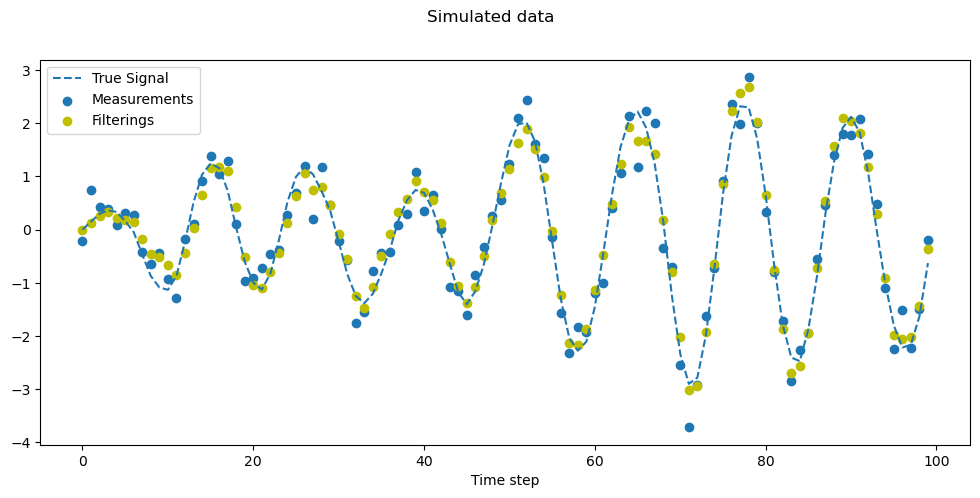

In [252]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(states[:, 0], linestyle='--', label="True Signal")
ax.scatter(np.arange(T), observations, marker='o', label="Measurements")
ax.scatter(np.arange(T), M[:, 0], marker='o', color = 'y', label="Filterings")
ax.set_xlabel("Time step")
ax.legend(loc="upper left")
fig.suptitle("Simulated data")

In [258]:
# compare performance with RMSE 

def rmse(y_true, y_pred):
    """
    Calculate Root Mean Square Error (RMSE).
    
    Parameters:
    y_true : array-like
        True values
    y_pred : array-like
        Predicted values
    
    Returns:
    float
        RMSE value
    """
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred))**2))

In [259]:
rmse([1,2], [0,0])

1.5811388300841898

In [261]:
rmse_measurements = rmse(states[:,0], observations)
rmse_bfiltering = rmse(states[:,0], M[:,0])

In [264]:
print(f'RMSE of measurements is {rmse_measurements:0.2f}, and RMSE of bayesian filtering is {rmse_bfiltering:0.2f}')

RMSE of measurements is 0.36, and RMSE of bayesian filtering is 0.23


## Exercise 6.5 

### Simulation

In [303]:
states = [0, 1]
p0 = [0.5, 0.5]

A = np.array([[0.8, 0.2], [0.1, 0.9]])
H = np.array([[0.7, 0.3], [0.7, 0.3]]) 

In [343]:
def transform_x(x):
    x_array = np.empty(2)
    x_array[x] = 1
    x_array[1-x] = 0
    return x_array

def inv_transform_x(x_array):
    '''
    Input is array, transform back to value 
    '''
    return 1 - x_array[0]

def get_sample(states, probas):
    val = np.random.choice(states, 1, p = probas)
    val_array = transform_x(val)
    return val_array

def get_measurement(x, states, H):
    y = get_sample(states, x@H)
    return y 


In [344]:
x0 = get_sample(states, p0)
x0

array([1., 0.])

In [345]:
inv_transform_x(x0)

0.0

In [339]:
# Simulation

X = np.empty((T, 2))
Y = np.empty((T, 2))

X[0] = x0   
Y[0] = get_measurement(x0, states, H)

for i in range(1, T):    
    X[i] = get_sample(states, X[i-1] @ A)
    Y[i] = get_measurement(X[i], states, H)
    
    

In [354]:
x_list = [1 + inv_transform_x(x) for x in X]
y_list = [1 + inv_transform_x(y) for y in Y]

In [359]:
res_list = np.array([a == b for a, b in zip(x_list, y_list)])

In [360]:
res_list.sum()

32

### HMM filter 

In [ ]:
def hmm_filter(p0, obs):
    
    